<a href="https://colab.research.google.com/github/Gennadiy-Korobeynikov/membrane_segmentation/blob/main/membrane_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir /content/dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/colab\ data/membrane_train.zip -d /content/dataset

Archive:  /content/drive/MyDrive/colab data/membrane_train.zip
  inflating: /content/dataset/train/mask/9.png  
  inflating: /content/dataset/train/mask/3.png  
  inflating: /content/dataset/train/mask/24.png  
  inflating: /content/dataset/train/image/7.png  
  inflating: /content/dataset/train/mask/21.png  
  inflating: /content/dataset/train/mask/26.png  
  inflating: /content/dataset/train/mask/19.png  
  inflating: /content/dataset/train/mask/13.png  
  inflating: /content/dataset/train/mask/18.png  
  inflating: /content/dataset/train/mask/20.png  
  inflating: /content/dataset/train/mask/28.png  
  inflating: /content/dataset/train/mask/10.png  
  inflating: /content/dataset/train/mask/7.png  
  inflating: /content/dataset/train/mask/22.png  
  inflating: /content/dataset/train/mask/5.png  
  inflating: /content/dataset/train/mask/23.png  
  inflating: /content/dataset/train/mask/0.png  
  inflating: /content/dataset/train/image/9.png  
  inflating: /content/dataset/train/mask/2

In [ ]:
import torch
import cv2
import os
import numpy as np
from google.colab.patches import cv2_imshow

In [ ]:
imgs_path = "/content/dataset/train/image"
masks_path = "/content/dataset/train/mask"

In [ ]:
print("Количество примеров =" , len(os.listdir(imgs_path)))
print("Количество масок =",  len(os.listdir(masks_path)))

Количество примеров = 30
Количество масок = 30


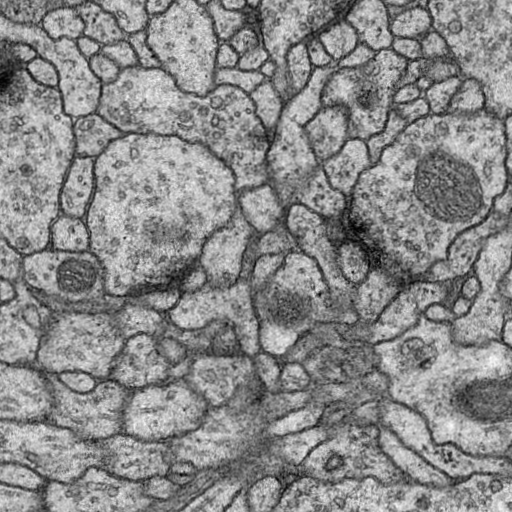

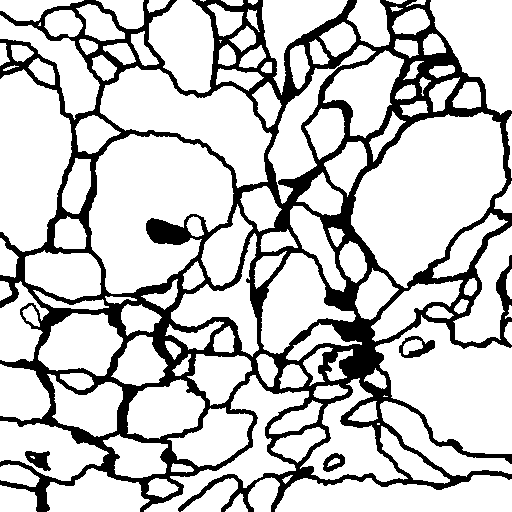

In [ ]:
img_test = cv2.imread("/content/dataset/train/image/0.png")
mask_test = cv2.imread("/content/dataset/train/mask/0.png")
cv2_imshow(img_test)
cv2_imshow(mask_test)

In [ ]:
print("Размерности ищображений =",img_test.shape)

Размерности ищображений = (512, 512, 3)


In [ ]:
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from sklearn.model_selection import KFold
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
class CellMembraneDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        img = Image.fromarray(cv2.imread(img_path, cv2.IMREAD_GRAYSCALE))
        mask = Image.fromarray(cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE))

        if self.transform:
            img = self.transform(img)
            mask = self.transform(mask)

        mask = (mask > 0).float()

        return img, mask

In [ ]:
transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.ToTensor()
])


In [ ]:
full_dataset = CellMembraneDataset(imgs_path, masks_path, transform=transforms)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
for img, mask in full_dataset:
  print(img, mask)

tensor([[[0.4863, 0.5098, 0.5373,  ..., 0.6157, 0.6039, 0.6157],
         [0.5059, 0.5922, 0.5569,  ..., 0.5765, 0.5765, 0.6118],
         [0.4235, 0.5569, 0.5412,  ..., 0.6039, 0.6549, 0.7529],
         ...,
         [0.7412, 0.6980, 0.6275,  ..., 0.6078, 0.4627, 0.4706],
         [0.6353, 0.6471, 0.5725,  ..., 0.7451, 0.5961, 0.4627],
         [0.6039, 0.6392, 0.5686,  ..., 0.8314, 0.7020, 0.6000]]]) tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]])
tensor([[[0.4863, 0.4392, 0.3255,  ..., 0.5765, 0.5059, 0.5059],
         [0.4549, 0.3765, 0.3137,  ..., 0.4824, 0.5373, 0.5725],
         [0.3882, 0.3686, 0.3765,  ..., 0.4824, 0.5176, 0.5765],
         ...,
         [0.4275, 0.4431, 0.4353,  ..., 0.7020, 0.6784, 0.6118],
         [0.4863, 0.5098, 0.4941,  ..., 0.7412, 0.7020, 0.

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, stride=stride),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

class DeconvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

In [ ]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        # Downsampling — через stride=2
        self.enc1 = ConvBlock(1, 32, stride=1)     # 1x256x256 → 32x256x256
        self.enc2 = ConvBlock(32, 64, stride=2)    # 64x128x128
        self.enc3 = ConvBlock(64, 128, stride=2)   # 128x64x64
        self.enc4 = ConvBlock(128, 256, stride=2)  # 256x32x32

        # Bottleneck
        self.bottleneck = ConvBlock(256, 512, stride=1)

        # Upsampling
        self.dec4 = DeconvBlock(512, 256)          # 256x64x64
        self.dec3 = DeconvBlock(256, 128)          # 128x128x128
        self.dec2 = DeconvBlock(128, 64)           # 64x256x256
        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, kernel_size=1),       # 1x256x256
            nn.Sigmoid()
        )

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(x1)
        x3 = self.enc3(x2)
        x4 = self.enc4(x3)

        x = self.bottleneck(x4)

        x = self.dec4(x)
        x = self.dec3(x)
        x = self.dec2(x)
        x = self.dec1(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
device

device(type='cuda')

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50):
    model.to(device)
    train_losses = []
    val_losses = []

    for epoch in tqdm(range(num_epochs)):
        model.train()
        train_loss = 0.0
        for images, masks in train_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(outputs, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        # Валидация
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)
                #outputs = outputs.squeeze(1)
                loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)

        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

    # График
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    return model

Fold 0
[ 0  1  2  3  4  5  6  7 10 11 12 13 14 16 18 19 20 21 22 24 25 26 28 29] [ 8  9 15 17 23 27]


  1%|          | 1/150 [00:00<02:17,  1.08it/s]

Epoch [1/150]  Train Loss: 0.6967  Val Loss: 0.6946


  1%|▏         | 2/150 [00:01<02:08,  1.15it/s]

Epoch [2/150]  Train Loss: 0.6932  Val Loss: 0.6911


...

Epoch [148/150]  Train Loss: 0.2039  Val Loss: 0.2251


 99%|█████████▉| 149/150 [02:10<00:00,  1.02it/s]

Epoch [149/150]  Train Loss: 0.2021  Val Loss: 0.2204


100%|██████████| 150/150 [02:11<00:00,  1.14it/s]

Epoch [150/150]  Train Loss: 0.2015  Val Loss: 0.2177


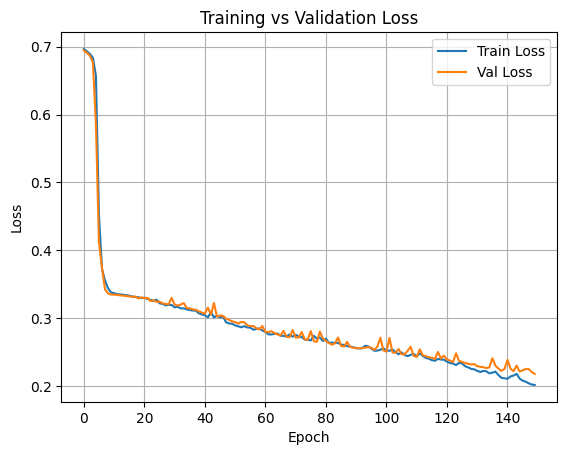

In [ ]:
for fold, (train_idx, val_idx) in enumerate(kfold.split(full_dataset)):
  print(f"Fold {fold}")
  print(train_idx, val_idx)

  train_subset = Subset(full_dataset, train_idx)
  val_subset = Subset(full_dataset, val_idx)

  train_loader = DataLoader(train_subset, batch_size=4, shuffle=True)
  val_loader = DataLoader(val_subset, batch_size=4, shuffle=False)

  model = Model().to(device)  # Новый экземпляр модели на каждый фолд
  optimizer = optim.Adam(model.parameters(), lr=1e-4)
  criterion = nn.BCELoss()

  trained_model = train_model(model, train_loader, val_loader,criterion, optimizer, num_epochs=150)
  break


In [ ]:
from torchvision import transforms
img_path = "/content/dataset/train/image/9.png"
mask_path = "/content/dataset/train/mask/9.png"


img = Image.open(img_path).convert("L")
mask = Image.open(mask_path).convert("L")

transform = transforms.Compose([
    transforms.ToTensor(),
])

input_tensor = transform(img).unsqueeze(0).to(device)
model.eval()
trained_model.eval()
with torch.no_grad():
    pred = trained_model(input_tensor)
    pred = pred.squeeze().cpu().numpy()

In [ ]:
pred

array([[0.7196145 , 0.8066058 , 0.8304283 , ..., 0.80608183, 0.78176755,
        0.6960809 ],
       [0.81361544, 0.9055379 , 0.9254663 , ..., 0.9041465 , 0.8799971 ,
        0.7787873 ],
       [0.8449643 , 0.93102705, 0.94724333, ..., 0.9262826 , 0.9034162 ,
        0.8019017 ],
       ...,
       [0.8156455 , 0.9062681 , 0.92480844, ..., 0.90706396, 0.8853002 ,
        0.7842391 ],
       [0.78886503, 0.88219327, 0.9017355 , ..., 0.88588685, 0.86264044,
        0.7626461 ],
       [0.70264935, 0.78571796, 0.80690813, ..., 0.7918515 , 0.7689583 ,
        0.6850228 ]], dtype=float32)

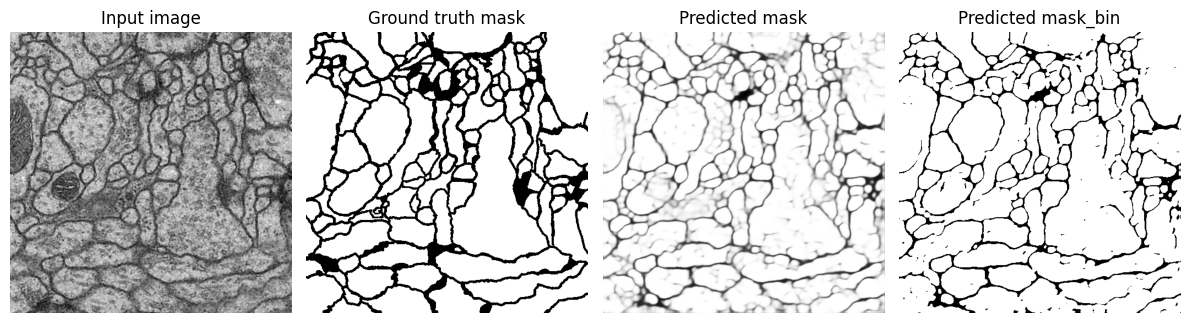

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(12, 4))

pred_bin = (pred>0.7)

axs[0].imshow(img, cmap='gray')
axs[0].set_title("Input image")

axs[1].imshow(mask, cmap='gray')
axs[1].set_title("Ground truth mask")

axs[2].imshow(pred, cmap='gray')
axs[2].set_title("Predicted mask")

axs[3].imshow(pred_bin, cmap='gray')
axs[3].set_title("Predicted mask_bin")

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()

Самостоятельная разметка:

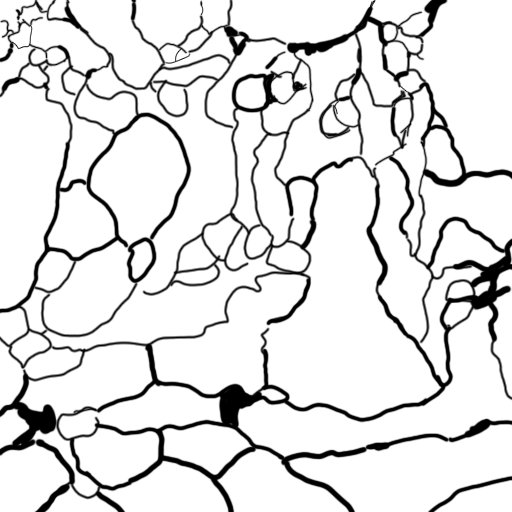